In [1]:
%reload_ext autoreload
%autoreload 2
import sinter
import matplotlib.pyplot as plt
import os

from qecdec.experiments import RotatedSurfaceCode_Memory
from qecdec.decoders import BPDecoder
from qecdec.sinter_utils import QecdecSinterDecoder

In [2]:
def generate_sinter_tasks_and_custom_decoders():
    tasks: list[sinter.Task] = []
    custom_decoders: dict[str, sinter.Decoder] = {}
    for d in [5, 7, 9, 11]:
        for p in [0.004, 0.006, 0.008, 0.01, 0.012]:
            # Setup the experiment.
            expmt = RotatedSurfaceCode_Memory(
                d=d,
                rounds=d,
                basis="Z",
                data_qubit_error_rate=p,
                meas_error_rate=p,
                prep_error_rate=p,
                gate1_error_rate=p,
                gate2_error_rate=p,
            )

            # Setup a sinter.Task with MWPM decoder.
            tasks.append(
                sinter.Task(
                    circuit=expmt.circuit,
                    detector_error_model=expmt.dem,
                    decoder="pymatching",
                    json_metadata={"d": d, "p": p, "decoder": "pymatching"},
                )
            )

            # Setup a sinter.Task with BP decoder.
            bp = BPDecoder(expmt.chkmat, expmt.prior, max_iter=50)
            custom_decoder_id = f"custom_decoder_{len(custom_decoders)}"
            custom_decoders[custom_decoder_id] = QecdecSinterDecoder(bp, expmt.obsmat)
            tasks.append(
                sinter.Task(
                    circuit=expmt.circuit,
                    detector_error_model=expmt.dem,
                    decoder=custom_decoder_id,
                    json_metadata={"d": d, "p": p, "decoder": "bp"},
                )
            )
    return tasks, custom_decoders


tasks, custom_decoders = generate_sinter_tasks_and_custom_decoders()


In [3]:
sinter_stats = sinter.collect(
    num_workers=os.cpu_count() - 1,
    max_shots=10_000_000,
    max_errors=100,
    tasks=tasks,
    custom_decoders=custom_decoders,
    print_progress=False,
)

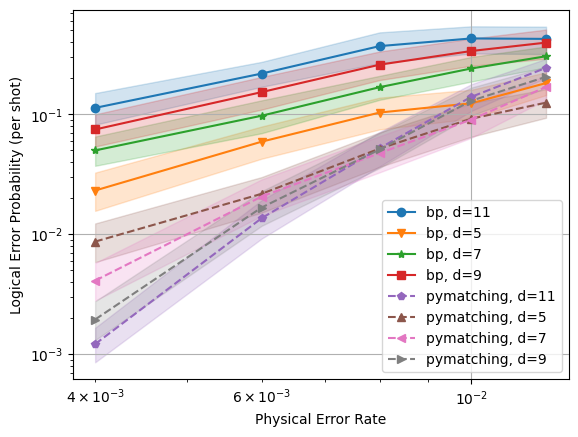

In [4]:
fig, ax = plt.subplots(1, 1)
sinter.plot_error_rate(
    ax=ax,
    stats=sinter_stats,
    group_func=lambda stat: (
        f"{stat.json_metadata['decoder']}, d={stat.json_metadata['d']}"
    ),
    x_func=lambda stat: stat.json_metadata["p"],
    plot_args_func=lambda index, group_key: {
        "linestyle": "solid" if group_key[:2] == "bp" else "dashed",
    },
)
ax.loglog()
ax.grid()
ax.set_ylabel("Logical Error Probability (per shot)")
ax.set_xlabel("Physical Error Rate")
ax.legend()